# EDA — Personality Type Prediction

**Project step 1 of 3:** `eda.ipynb` → `modeling.ipynb` → `app.py`

This notebook builds on Live Session 1 (`JT_LS1_data_and_pipeline.ipynb`). It keeps the
data loading and the quick look from LS1 and adds the checks the submission asks for:

1. load `data/data.csv` and check its shape and types,
2. look for **missing** and **impossible** values,
3. check how **balanced** the target classes are,
4. look at the **distribution of the personality items**,
5. apply the cleaning decisions in **one place**,
6. save the result as **`data/data_processed.csv`** — the handoff to `modeling.ipynb`.

> The preprocessing **pipeline** from LS1 (imputing, scaling, one-hot encoding) now lives in
> `modeling.ipynb`. This notebook only *fixes* the data; it does not transform it for a model.

## 1. Load the data

In [108]:
# @title Setup: Environment and Data Loading
#https://drive.google.com/file/d/1lgycXDQapixkoWFxIg48qaYcrNl6uSZM/view?usp=sharing

import subprocess
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style="whitegrid")
from pathlib import Path
from IPython.display import HTML, clear_output, display

try:
    import gdown
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "-q", "install", "gdown"], check=True)
    import gdown

FILE_ID = "1lgycXDQapixkoWFxIg48qaYcrNl6uSZM"
MARKER_FILE = Path(f".downloaded_{FILE_ID}")

if MARKER_FILE.exists():
    print("Dataset already available.")
else:
    print("Downloading dataset...")
    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, quiet=False)
    MARKER_FILE.write_text(FILE_ID)
    clear_output()
    print("Download completed.")

Dataset already available.


In [109]:
df = pd.read_csv("data.csv")
display("Shape:", df.shape)
df.head()

'Shape:'

(19719, 23)

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,...,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,...,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,...,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,...,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,...,3,25,3,3,5,5,3,Female,Right,Moderate


In [110]:
counts = df["target"].value_counts()

target_overview = pd.DataFrame({
    "count": counts,
    "share_%": (counts / len(df) * 100).round(1),
})
target_overview.index.name = "personality type"
target_overview

,count,share_%
personality type,,
Moderate,8452,42.9
Resilient,6163,31.3
Overcontroller,2829,14.3
Undercontroller,2275,11.5


# 2. Target Analysis (y)

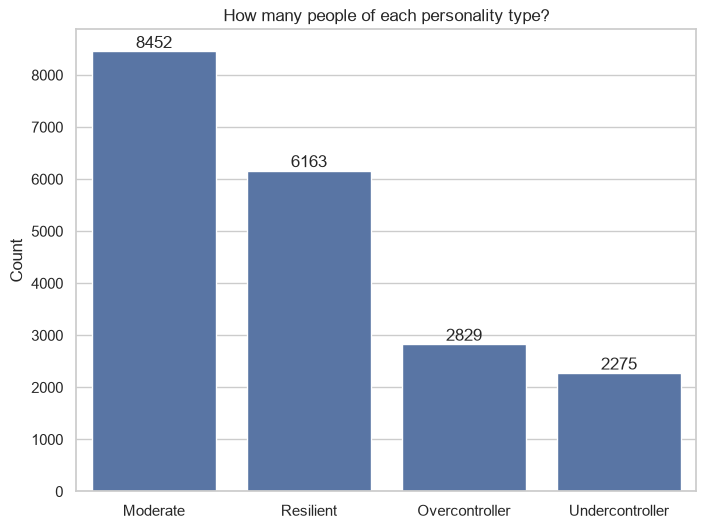

In [111]:
# What are we predicting? The personality type.
plt.figure(figsize=(8, 6))

ax = sns.countplot(data=df, x="target", order=df["target"].value_counts().index)
ax.bar_label(ax.containers[0])  # shows the count on each bar

plt.title("How many people of each personality type?")
plt.xlabel("")
plt.ylabel("Count")
plt.show()


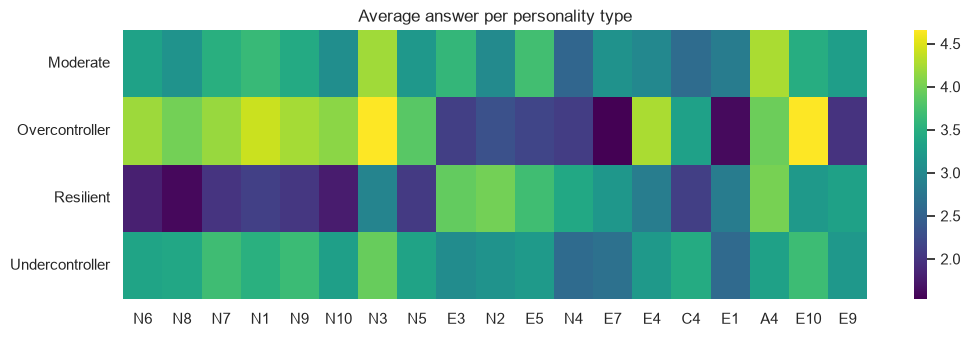

In [112]:
# The personality questions = every column except the demographics and target
item_cols = [c for c in df.columns if c not in ["age", "gender", "hand", "target"]]

# Average answer to each question, per personality type.
# This is the kind of signal the model will learn from.
plt.figure(figsize=(12, 3.5))
sns.heatmap(df.groupby("target")[item_cols].mean(), cmap="viridis")
plt.title("Average answer per personality type")
plt.ylabel("")
plt.show()

#Exploratory Data Analysis (EDA)

### 2.1 Structure, data types and missing values

One row = one person. Before modelling we check the column types, gaps and duplicates.

In [113]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19719 entries, 0 to 19718
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   N6      19719 non-null  int64
 1   N8      19719 non-null  int64
 2   N7      19719 non-null  int64
 3   N1      19719 non-null  int64
 4   N9      19719 non-null  int64
 5   N10     19719 non-null  int64
 6   N3      19719 non-null  int64
 7   N5      19719 non-null  int64
 8   E3      19719 non-null  int64
 9   N2      19719 non-null  int64
 10  E5      19719 non-null  int64
 11  N4      19719 non-null  int64
 12  E7      19719 non-null  int64
 13  E4      19719 non-null  int64
 14  age     19719 non-null  int64
 15  C4      19719 non-null  int64
 16  E1      19719 non-null  int64
 17  A4      19719 non-null  int64
 18  E10     19719 non-null  int64
 19  E9      19719 non-null  int64
 20  gender  19695 non-null  str  
 21  hand    19619 non-null  str  
 22  target  19719 non-null  str  
dtypes: int64(20), str(3)
m

In [114]:
df.describe()

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9
count,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,1.971900e+04,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000
mean,2.980374,2.803235,3.151935,3.262082,3.135250,2.833764,3.842690,2.951722,3.416755,3.234596,3.432223,2.756276,2.867285,3.152036,5.076703e+04,2.654242,2.628937,4.030073,3.585324,3.094275
std,1.320437,1.350648,1.299910,1.308169,1.298573,1.313036,1.138854,1.272889,1.236820,1.177018,1.282003,1.220964,1.431814,1.222822,7.121272e+06,1.243191,1.232565,1.045403,1.304571,1.396490
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.800000e+01,2.000000,2.000000,4.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.200000e+01,3.000000,3.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,3.100000e+01,4.000000,4.000000,5.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000e+09,5.000000,5.000000,5.000000,5.000000,5.000000


In [115]:
# Missing values per column (only columns that have any)
missing = df.isna().sum()
print("Missing values:")
print(missing[missing > 0])
print()
print("Exact duplicate rows:", df.duplicated().sum())
df[df.duplicated()]

Missing values:
gender     24
hand      100
dtype: int64

Exact duplicate rows: 3


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
13093,5,5,5,5,5,5,5,5,5,5,...,5,21,5,5,5,5,5,Male,Right,Moderate
16591,5,5,5,5,5,5,5,5,5,5,...,5,18,5,5,5,5,5,Male,Right,Moderate
17685,5,5,5,5,5,5,5,5,5,5,...,5,23,5,5,5,5,5,Male,Right,Moderate


### 2.2 The question scores

The instructions say every answer is on a 1–5 scale. Let's check if this is really true.

In [116]:
df[item_cols].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
N6,2.98,1.32,0.0,5.0
N8,2.80,1.35,0.0,5.0
N7,3.15,1.30,0.0,5.0
N1,3.26,1.31,0.0,5.0
N9,3.14,1.30,0.0,5.0
N10,2.83,1.31,0.0,5.0
N3,3.84,1.14,0.0,5.0
N5,2.95,1.27,0.0,5.0
E3,3.42,1.24,0.0,5.0
N2,3.23,1.18,0.0,5.0


Are any answers outside the 1-5 scale?

In [117]:
out_of_range = (df[item_cols] < 1) | (df[item_cols] > 5)
print("Answers outside 1-5:", out_of_range.sum().sum())
print("Rows affected:     ", out_of_range.any(axis=1).sum())
df[out_of_range.any(axis=1)]

Answers outside 1-5: 19
Rows affected:      1


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19064,0,0,0,0,0,0,0,0,0,0,...,0,52,0,0,0,0,0,Female,Right,Resilient


A total of 19 rows have at least one 0 answer that is out of scale. One person answered all out of scale and should be removed along with the other 18.

How are the answers distributed?

Share of people giving each answer, per question.

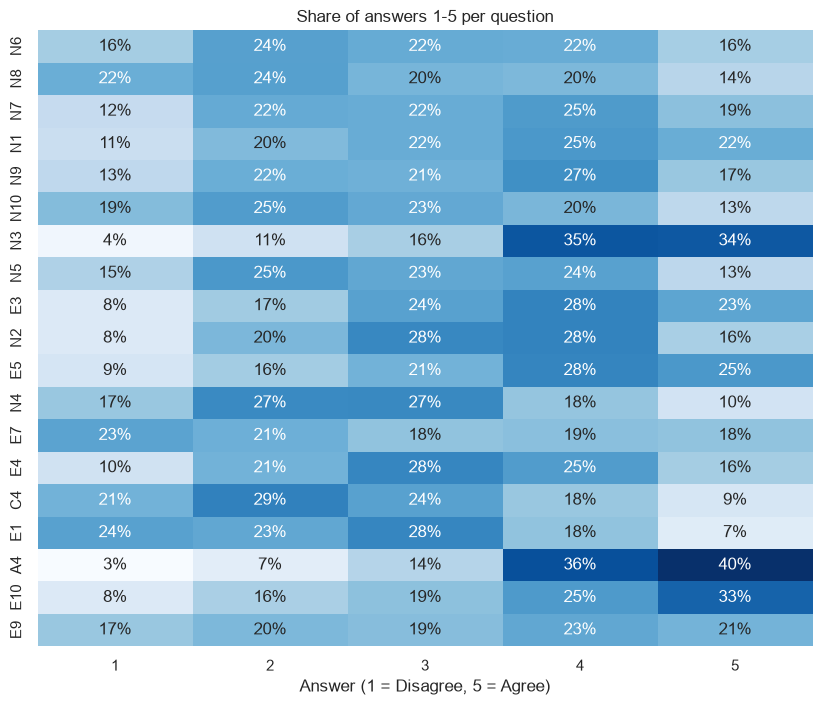

In [118]:
answer_share = (
    df[item_cols]
    .apply(lambda col: col.value_counts(normalize=True))
    .reindex([1, 2, 3, 4, 5])
    .T
)

plt.figure(figsize=(10, 8))
sns.heatmap(answer_share, annot=True, fmt=".0%", cmap="Blues", cbar=False)
plt.title("Share of answers 1-5 per question")
plt.xlabel("Answer (1 = Disagree, 5 = Agree)")
plt.show()

### 2.3 Correlations between the questions

The column names tell us which OCEAN trait a question belongs to (N = Neuroticism, E = Extraversion,
C = Conscientiousness, A = Agreeableness).

The 19 items are not spread evenly across the traits. Ten measure Neuroticism and seven Extraversion, but Conscientiousness and Agreeableness have only one item each (C4, A4). Since Undercontroller is defined precisely by C and A, the information needed to spot that type is largely missing from the data. This explains directly why the model only catches ~20% of Undercontrollers while getting most of the Resilients.

In [119]:
# Count of questions per trait
pd.Series([c[0] for c in item_cols]).value_counts().rename({"N": "Neuroticism", "E": "Extraversion", "C": "Conscientiousness", "A": "Agreeableness"})

Neuroticism          10
Extraversion          7
Conscientiousness     1
Agreeableness         1
Name: count, dtype: int64

### Every question against the personality type

A `countplot` per column, split by `target`. For each answer (1–5) we see how the four
personality types are distributed. Where the coloured blocks shift from left to right
between the types, that question separates them — that is the signal the model will learn.

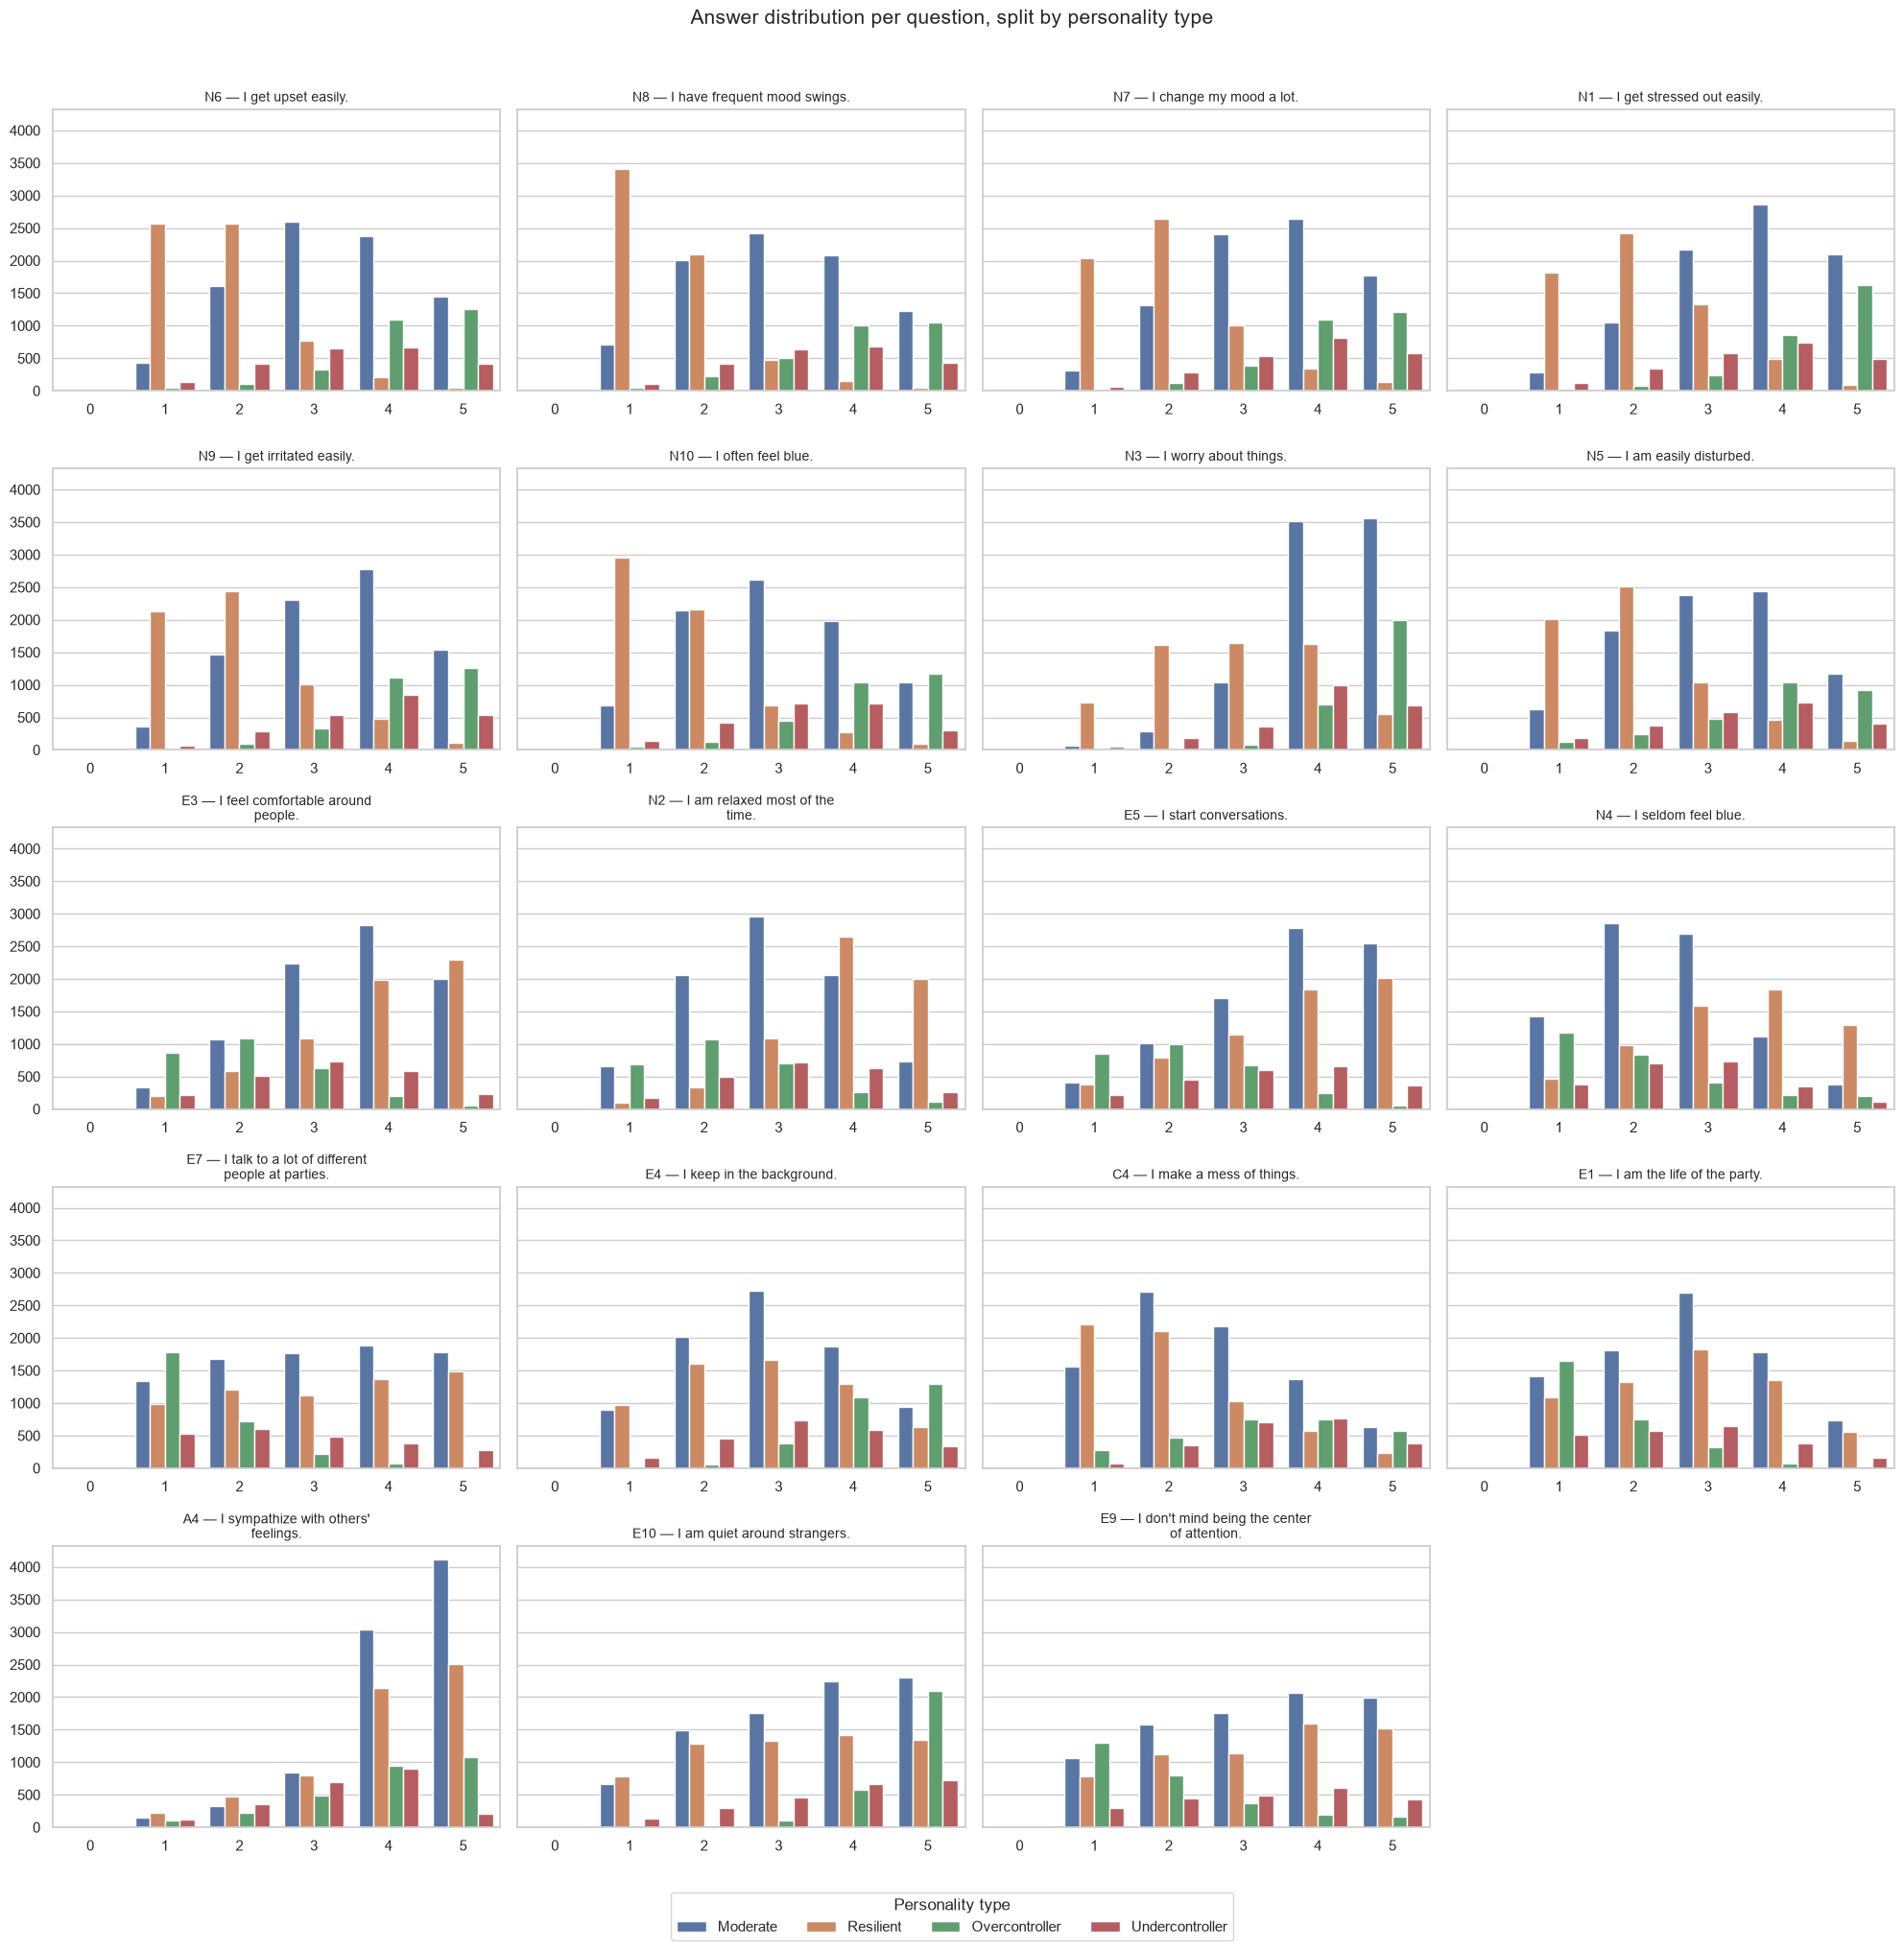

In [120]:
import textwrap
item_labels = {
    "N1":  "I get stressed out easily.",
    "N2":  "I am relaxed most of the time.",
    "N3":  "I worry about things.",
    "N4":  "I seldom feel blue.",
    "N5":  "I am easily disturbed.",
    "N6":  "I get upset easily.",
    "N7":  "I change my mood a lot.",
    "N8":  "I have frequent mood swings.",
    "N9":  "I get irritated easily.",
    "N10": "I often feel blue.",
    "E1":  "I am the life of the party.",
    "E3":  "I feel comfortable around people.",
    "E4":  "I keep in the background.",
    "E5":  "I start conversations.",
    "E7":  "I talk to a lot of different people at parties.",
    "E9":  "I don't mind being the center of attention.",
    "E10": "I am quiet around strangers.",
    "C4":  "I make a mess of things.",
    "A4":  "I sympathize with others' feelings.",
}

order = df["target"].value_counts().index
n, ncols = len(item_cols), 4
nrows = -(-n // ncols)          # round up

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), sharey=True)

for i, (ax, col) in enumerate(zip(axes.flat, item_cols)):
    # only the first plot draws a legend — we reuse its colours for the whole grid
    sns.countplot(data=df, x=col, hue="target", hue_order=order, ax=ax, legend=(i == 0))
    title = f"{col} — {item_labels.get(col, '')}"
    ax.set_title("\n".join(textwrap.wrap(title, 34)), fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty axes in the last row
for ax in axes.flat[n:]:
    ax.remove()

# one shared legend for the whole figure
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].get_legend().remove()
fig.legend(handles, labels, title="Personality type",
           loc="lower center", bbox_to_anchor=(0.5, -0.01), ncol=4)

fig.suptitle("Answer distribution per question, split by personality type", fontsize=15, y=1.0)
plt.tight_layout(rect=[0, 0.03, 1, 0.985])
plt.show()

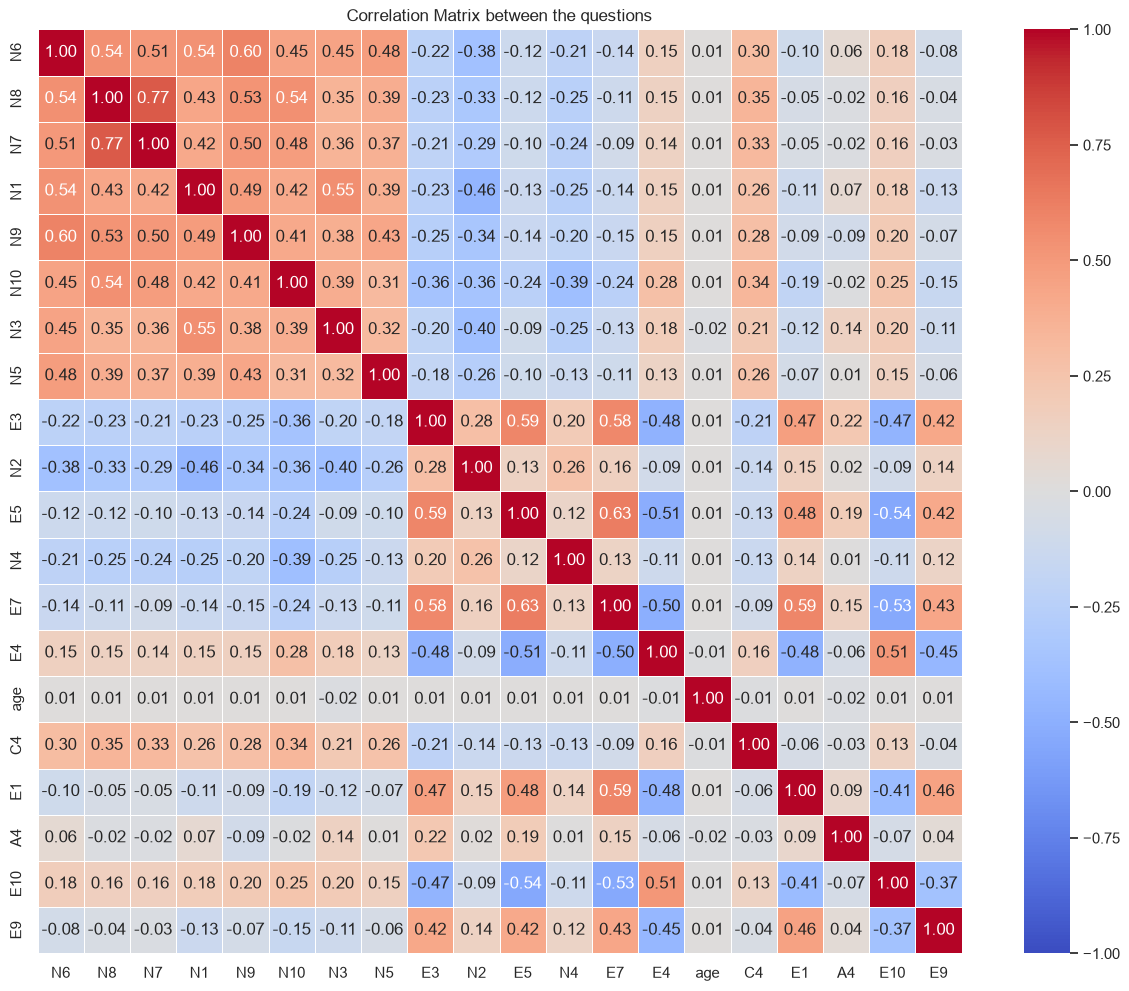


Strongest positive pairs:


N8  N7    0.77
E5  E7    0.63
N6  N9    0.60
E3  E5    0.59
E7  E1    0.59
dtype: float64


Strongest negative pairs:


E5  E10   -0.54
E7  E10   -0.53
E5  E4    -0.51
E7  E4    -0.50
E4  E1    -0.48
dtype: float64

In [121]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Compute correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", annot=True,fmt=".2f", vmin=-1, vmax=1, center=0, square=True, linewidths=0.5)
plt.title("Correlation Matrix between the questions")
plt.show()

# Strongest pairs (each pair only once)
pairs = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
print("\nStrongest positive pairs:")
display(pairs.sort_values(ascending=False).head(5).round(2))
print()
print("Strongest negative pairs:")
display(pairs.sort_values().head(5).round(2))

### 2.4 Age Analysis — looking for outliers

Age is messy. The maximum is 990,000,000. 83 values are over 100, and several look like birth years that were typed in (1961, 1974, 1984…). The minimum is 13, and about 1,450 people are under 16. We need a rule here, for example treating anything outside a plausible range (say 13–100) as missing and imputing the median.

In [122]:
df["age"].describe().round(1)

count        19719.0
mean         50767.0
std        7121271.9
min             13.0
25%             18.0
50%             22.0
75%             31.0
max      999999999.0
Name: age, dtype: float64

In [123]:
df["age"].value_counts() #shows the number of occurrences of each unique value in the "age" column

age
18      1523
17      1370
19      1259
20      1231
21      1216
        ... 
99         1
191        1
78         1
1964       1
118        1
Name: count, Length: 104, dtype: int64

In [124]:
print("Ages above 100:", (df["age"] > 100).sum())
display("Some of those values:", sorted(df.loc[df["age"] > 100, "age"].unique())[:15])
print("Ages below 13:  ", (df["age"] < 13).sum())
print("Ages 13-15:     ", df["age"].between(13, 15).sum())

Ages above 100: 83


'Some of those values:'

[np.int64(118),
 np.int64(188),
 np.int64(191),
 np.int64(208),
 np.int64(211),
 np.int64(223),
 np.int64(266),
 np.int64(1961),
 np.int64(1964),
 np.int64(1968),
 np.int64(1974),
 np.int64(1976),
 np.int64(1977),
 np.int64(1982),
 np.int64(1984)]

Ages below 13:   0
Ages 13-15:      1456


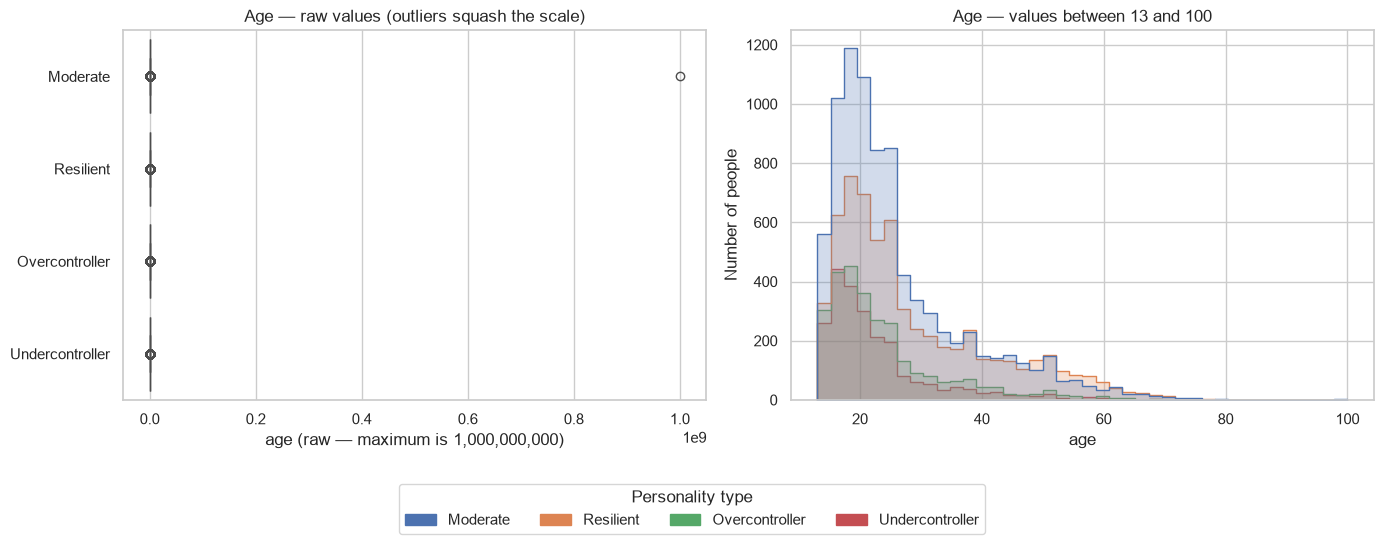

In [125]:
order = df["target"].value_counts().index

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw values — the extreme outliers squash everything else
sns.boxplot(data=df, x="age", y="target", hue="target",
            order=order, hue_order=order, legend=False, ax=axes[0])
axes[0].set_title("Age — raw values (outliers squash the scale)")
axes[0].set_ylabel("")
axes[0].set_xlabel("age (raw — maximum is 1,000,000,000)")

# Right: plausible range only
plausible = df[df["age"].between(13, 100)]
sns.histplot(data=plausible, x="age", hue="target", hue_order=order,
             bins=40, element="step", ax=axes[1])
axes[1].set_title("Age — values between 13 and 100")
axes[1].set_ylabel("Number of people")
axes[1].get_legend().remove()

# One shared, coloured legend for both panels
handles = [plt.Rectangle((0, 0), 1, 1, color=c)
           for c in sns.color_palette(n_colors=len(order))]
fig.legend(handles, list(order), title="Personality type",
           loc="lower center", bbox_to_anchor=(0.5, -0.10), ncol=4)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

We chose the boxenplot because a plain boxplot would just show hundreds of outlier dots on this large data set.

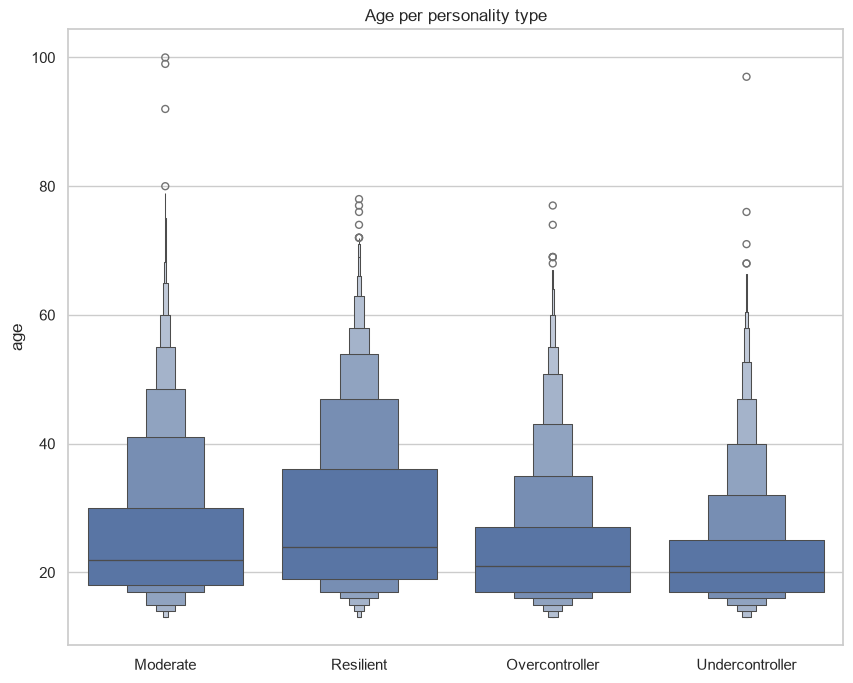

In [126]:
# Does age differ between the personality types? (plausible ages only: 13-100)
plt.figure(figsize=(10, 8))
sns.boxenplot(data=df[df["age"].between(13, 100)], x="target", y="age",
            order=df["target"].value_counts().index)
plt.title("Age per personality type")
plt.xlabel("")
plt.show()

Age is strongly skewed toward young respondents (73 % under 30) in every personality type.

Resilient people with the widest spread (Q3 at 36 vs. 25) are slightly older (median 24) and Undercontrollers slightly younger (median 20), but the distributions overlap so heavily that **age alone barely separates the classes — the predictive signal comes from the questionnaire answers.**

### 2.5 Gender and hand - missing categories

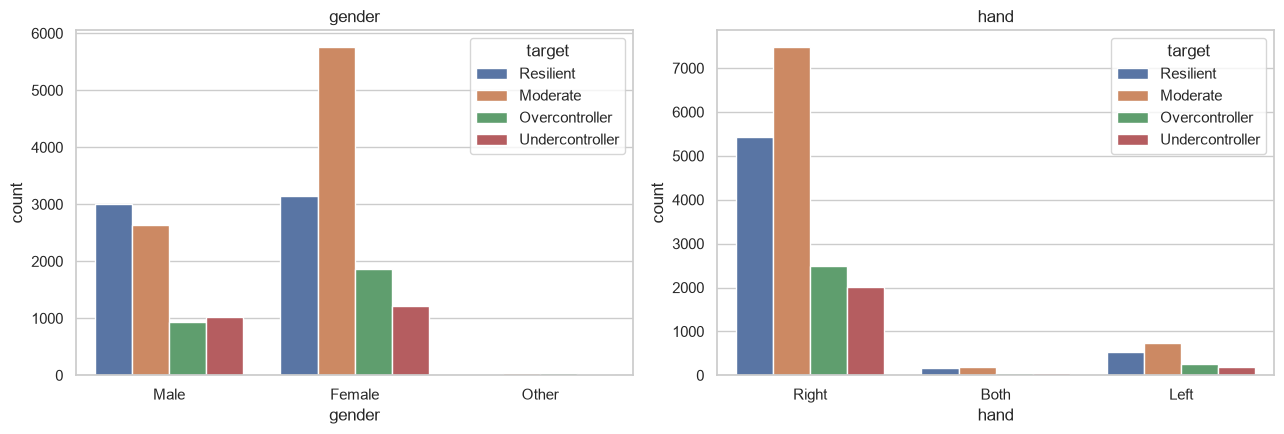

In [127]:
plt.figure(figsize=(13, 4.5))

for i, col in enumerate(["gender", "hand"], start=1):
    plt.subplot(1, 2, i)
    sns.countplot(df, x=col, hue="target")
    plt.title(col)

plt.tight_layout()
plt.show()

124 missing cells across 120 rows (gender 24, hand 100 — so 4 people are missing both)

In [128]:
for col in ["gender", "hand"]:
    print(df[col].value_counts(dropna=False), "\n")
df

gender
Female    11985
Male       7608
Other       102
NaN          24
Name: count, dtype: int64 

hand
Right    17424
Left      1724
Both       471
NaN        100
Name: count, dtype: int64 



,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,...,E4,age,C4,E1,A4,E10,E9,gender,hand,target
0,1,1,1,1,1,1,2,1,5,5,...,2,53,1,4,5,1,5,Male,Right,Resilient
1,4,2,3,2,2,4,4,3,3,3,...,3,46,2,2,4,5,1,Female,Right,Moderate
2,5,5,5,5,5,5,5,5,1,1,...,4,14,1,5,5,1,5,Female,Right,Moderate
3,5,5,5,5,4,5,4,4,2,4,...,4,19,5,2,4,5,4,Female,Right,Overcontroller
4,3,3,3,3,3,4,3,3,3,3,...,3,25,3,3,5,5,3,Female,Right,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19714,5,4,4,5,4,4,5,4,3,3,...,5,15,3,1,5,5,1,Female,Right,Overcontroller
19715,2,2,2,2,2,2,2,3,2,4,...,3,37,2,2,4,4,4,Female,Right,Resilient
19716,5,5,5,5,5,5,5,5,4,1,...,5,16,5,2,2,5,1,Male,Right,Overcontroller
19717,4,4,4,4,4,4,5,4,2,3,...,3,16,2,1,4,5,4,Male,Right,Overcontroller


To see whether the personality split actually differs between groups, we need the shares within each group

In [129]:
# Share of each personality type within each group (rows add up to 1)
for col in ["gender", "hand"]:
    display(pd.crosstab(df[col], df["target"], normalize="index").round(2))

target,Moderate,Overcontroller,Resilient,Undercontroller
gender,,,,
Female,0.48,0.16,0.26,0.10
Male,0.35,0.12,0.39,0.14
Other,0.39,0.31,0.12,0.18


target,Moderate,Overcontroller,Resilient,Undercontroller
hand,,,,
Both,0.40,0.12,0.35,0.13
Left,0.43,0.15,0.31,0.11
Right,0.43,0.14,0.31,0.12


Nearly identical rows — so hand tells you basically nothing. Gender does differ (Resilient is 39% among men vs. 26% among women).

### 2.6 Key findings from the EDA

- **Size:** 19,719 people, 23 columns — 19 question scores, `age`, `gender`, `hand` and the `target`.
- **Imbalanced classes:** Moderate ≈ 43 %, Resilient ≈ 31 %, Overcontroller ≈ 14 %, Undercontroller ≈ 12 %.
  A model that always says "Moderate" would already get ~43 % accuracy, so accuracy alone can be misleading.
- **The questions carry clear signal:** the Neuroticism questions (N…) separate Resilient (low answers) from Overcontroller (high answers). Some Extraversion questions correlate *negatively* with others —
  these are reverse-worded questions, which is fine for the models.
- **Invalid answers:** one row has `0` for all 19 questions. `0` is not on the 1–5 scale (in the original Kaggle data it means "not answered"), so this row is dropped.
- **Age has impossible values:** a maximum of 1,000,000,000, 83 ages above 100 — 73 of the 83 implausible ages look like birth years that were typed in; we removed them rather than guess the survey year. Median imputation would **not** fix these, and they would distort the scaling.
- **Missing values:** `gender` (24) and `hand` (100) — small, the pipeline's imputer handles them.
- **Duplicates:** 3 exact duplicate rows (in all numerical questions excet age). They have different ages but make no logical sense as the same rating in every class is partially contradicting.
- **Gender** shows some differences between types (e.g. more Resilient among men), **hand** hardly any.

## 2b. Clean the data before modelling

The pipeline fills gaps, but it cannot tell that an age of 1,000,000,000 is wrong. So we remove the problems found above **before** splitting into X and y. Every row is deleted where:

- all numerical columns have the exact same answer (see cell 68)
- `hand` is empty
- `gender` is empty
- an answer is `0`, because that is outside the allowed range of 1–5
- `age` is above 100 or below 13 — impossible values

In the Streamlit app the inputs are restricted (sliders 1–5, age 13–100, required dropdowns), so a new user cannot enter these kinds of values.

In [130]:
AGE_MIN, AGE_MAX = 13, 100

rows_before = len(df)
cleaning_log = []

def log(step, df):
    """Record how many rows this step removed."""
    previous = cleaning_log[-1][2] if cleaning_log else rows_before
    cleaning_log.append((step, previous - len(df), len(df)))

# 1. Exact duplicate rows
df = df.drop_duplicates()
log("1. Duplicate rows", df)

# 2. Answers outside the 1-5 scale (0 = "not answered" in the original data)
df = df[df[item_cols].isin([1, 2, 3, 4, 5]).all(axis=1)]
log("2. Answers outside 1-5", df)

# 3. Missing demographics
df = df.dropna(subset=["gender", "hand"])
log("3. Missing gender / hand", df)

# 4. Impossible ages
df = df[df["age"].between(AGE_MIN, AGE_MAX)]
log(f"4. Age outside {AGE_MIN}-{AGE_MAX}", df)

df = df.reset_index(drop=True)

# Overview: how many rows did each step remove?
summary = pd.DataFrame(cleaning_log, columns=["step", "rows_removed", "rows_left"])
display(summary)

print("Rows before:", rows_before)
print("Rows after: ", len(df))
print("Removed:    ", rows_before - len(df),
      f"({(rows_before - len(df)) / rows_before:.1%})")
print("\nMissing values left:", df.isna().sum().sum())
display(df["age"].describe().round(1))

,step,rows_removed,rows_left
0,1. Duplicate rows,3,19716
1,2. Answers outside 1-5,1,19715
2,3. Missing gender / hand,120,19595
3,4. Age outside 13-100,81,19514


Rows before: 19719
Rows after:  19514
Removed:     205 (1.0%)

Missing values left: 0


count    19514.0
mean        26.2
std         11.5
min         13.0
25%         18.0
50%         22.0
75%         31.0
max        100.0
Name: age, dtype: float64

We lose 205 rows, about 1%, and end at 19,514. The class balance barely moves (42.8 / 31.3 / 14.4 / 11.5), so nothing is distorted.

In [132]:
from pathlib import Path

Path('data').mkdir(parents=True, exist_ok=True)
df.to_csv("data/data_cleaned.csv", index=False)

## 3. Build the preprocessing pipeline

Models need fully numeric, comparable inputs. A `ColumnTransformer` prepares
every column in one object:

- numeric columns (the questions + `age`): fill missing values, then scale
- categorical columns (`gender`, `hand`): fill missing values, then one-hot encode

We keep the target as **text** (e.g. `"Resilient"`). scikit-learn models handle
string labels fine, and it means our predictions come out readable — no label
encoder needed.

In [133]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Features (X) and target (y). y stays as text labels.
X = df.drop(columns=["target"])
y = df["target"]

numeric_features = item_cols + ["age"]
categorical_features = ["gender", "hand"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]), categorical_features),
])

print("Data and preprocessor ready. Shape:", df.shape)

Data and preprocessor ready. Shape: (19514, 23)


### What the preprocessor actually does

In [134]:
X_prepared = preprocessor.fit_transform(X)
print("Before:", X.shape, " After:", X_prepared.shape)
# Notice the column count changes — gender/hand became several 0/1 columns.

Before: (19514, 22)  After: (19514, 26)


In [135]:
# Which columns come out of the preprocessor?
feature_names = preprocessor.get_feature_names_out()
print(list(feature_names[-8:]))

# First rows after preprocessing: scaled numbers + 0/1 columns, and no gaps left
prepared_df = pd.DataFrame(X_prepared, columns=feature_names)
print("Missing values after preprocessing:", int(prepared_df.isna().sum().sum()))
prepared_df.head().round(2)

['num__E9', 'num__age', 'cat__gender_Female', 'cat__gender_Male', 'cat__gender_Other', 'cat__hand_Both', 'cat__hand_Left', 'cat__hand_Right']
Missing values after preprocessing: 0


,num__N6,num__N8,num__N7,num__N1,num__N9,num__N10,num__N3,num__N5,num__E3,num__N2,...,num__A4,num__E10,num__E9,num__age,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__hand_Both,cat__hand_Left,cat__hand_Right
0,-1.50,-1.34,-1.66,-1.73,-1.64,-1.40,-1.62,-1.53,1.28,1.50,...,0.93,-1.98,1.37,2.32,0.0,1.0,0.0,0.0,0.0,1.0
1,0.77,-0.60,-0.12,-0.97,-0.87,0.89,0.14,0.04,-0.34,-0.20,...,-0.03,1.08,-1.50,1.71,1.0,0.0,0.0,0.0,0.0,1.0
2,1.53,1.63,1.42,1.33,1.44,1.65,1.02,1.61,-1.96,-1.90,...,0.93,-1.98,1.37,-1.06,1.0,0.0,0.0,0.0,0.0,1.0
3,1.53,1.63,1.42,1.33,0.67,1.65,0.14,0.82,-1.15,0.65,...,-0.03,1.08,0.65,-0.63,1.0,0.0,0.0,0.0,0.0,1.0
4,0.01,0.15,-0.12,-0.20,-0.10,0.89,-0.74,0.04,-0.34,-0.20,...,0.93,1.08,-0.07,-0.11,1.0,0.0,0.0,0.0,0.0,1.0


In [136]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['Moderate','Overcontroller','Resilient','Undercontroller']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['N6','N8','N7',...,'E9','gender','hand']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

## 4. Plug a model into the pipeline

We glue the preprocessor in front of a model, so the whole thing is **one object**. Here we first check the random forest model on a simple train/test split and read the **classification report**, which scores each class separately.

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("Accuracy on the test set:", round(accuracy_score(y_test, predictions), 3))
print()
print("A few predictions:", list(predictions[:5]))
print("Actual labels:    ", list(y_test[:5]))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy on the test set: 0.837

A few predictions: ['Moderate', 'Moderate', 'Resilient', 'Moderate', 'Moderate']
Actual labels:     ['Moderate', 'Moderate', 'Resilient', 'Moderate', 'Moderate']

Classification Report:
                 precision    recall  f1-score   support

       Moderate       0.78      0.92      0.84      1672
 Overcontroller       0.86      0.85      0.85       562
      Resilient       0.95      0.95      0.95      1221
Undercontroller       0.66      0.20      0.31       448

       accuracy                           0.84      3903
      macro avg       0.81      0.73      0.74      3903
   weighted avg       0.83      0.84      0.82      3903



The line we care about is **`macro avg` → `f1-score`**.

Macro F1 averages the F1 of every class **equally**, so a small class counts as much as a big one. That matters here because our classes are imbalanced (look
back at the target counts in LS1). From now on, **macro F1 is our single number** for comparing models.

### Is 0.84 accuracy actually good? A baseline for comparison

A "model" that always predicts the most common class shows how much accuracy we get for free.

In [138]:
from sklearn.dummy import DummyClassifier

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent")),
])
baseline.fit(X_train, y_train)
print("Baseline accuracy (always 'Moderate'):", round(accuracy_score(y_test, baseline.predict(X_test)), 3))

Baseline accuracy (always 'Moderate'): 0.428


In [139]:
# Accuracy per class: how often is each type predicted correctly?
per_class = (
    pd.DataFrame({"actual": y_test, "correct": predictions == y_test})
    .groupby("actual")["correct"].mean()
    .round(3)
    .sort_values()
)
per_class

actual
Undercontroller    0.199
Overcontroller     0.847
Moderate           0.923
Resilient          0.948
Name: correct, dtype: float64

Since Undercontroller is defined only by C and A, which only had one question each represented out of the 19 from dataset. This explains directly why the model only catches ~20% of Undercontrollers while getting most of the Resilients.

## Think about — answers

**Why might accuracy be misleading here?**
The classes are imbalanced. Always predicting "Moderate" already gives ~43 % accuracy without learning anything.
The overall accuracy of ~0.85 also hides big differences between the classes: the model recognises
Resilient and Moderate very well, but only about a quarter of the **Undercontrollers**. Because this is
the smallest class, it barely affects the overall accuracy. That is why Live Session 2 uses F1-macro,
which treats every class equally.

**What happens if a new user leaves a question blank?**
The pipeline handles it: the `SimpleImputer` fills a blank question with the median and a blank
gender/hand with the most frequent value, so the model still returns a prediction (tested above).
The prediction is based on a guessed value, though, so in the app it is better to make every answer required.

**RandomForest vs. LogisticRegression?**
Both reach about the same accuracy (~0.85), LogisticRegression is even slightly higher. The simpler,
linear model is enough here, probably because the answers relate to the types in a fairly straightforward
way (higher N-scores → more likely Overcontroller, lower → Resilient). A single split is not enough to pick
a winner — we compare them properly with cross-validation and F1-macro in Live Session 2.

## Recap & what's next

We loaded the data, looked at it, built a preprocessing **pipeline**, and
confirmed a model runs end-to-end through it.

In **Live Session 2** we evaluate models properly with cross-validation,
compare two of them, and tune them.

👉 **Your turn:** plug a different model into the pipeline (e.g.
`LogisticRegression`) and see whether the accuracy changes.

### Trying LogisticRegression instead of RandomForest

In [140]:
from sklearn.linear_model import LogisticRegression

log_reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

log_reg_model.fit(X_train, y_train)
log_reg_predictions = log_reg_model.predict(X_test)

print("RandomForest accuracy:      ", round(accuracy_score(y_test, predictions), 3))
print("LogisticRegression accuracy:", round(accuracy_score(y_test, log_reg_predictions), 3))

RandomForest accuracy:       0.837
LogisticRegression accuracy: 0.853
